# 04 — Modeling & Evaluation (Deliverable D)

D1-D9, then figures 10-12 (which need this notebook's trained model), then the
final refit-on-all-data model is saved and used to fill the submission file.

In [1]:
import sys, os
sys.path.append(os.path.join('..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.base import clone

from features import CATEGORICAL_FEATURES, NUMERIC_FEATURES, MODEL_FEATURES, TARGET_COLUMN

PROCESSED = os.path.join('..', 'data', 'processed')
ASSETS = os.path.join('..', 'app', 'assets')
FIGURES = os.path.join('..', 'figures')
MODELS = os.path.join('..', 'models')
SUBMISSION_DIR = os.path.join('..', 'submission')
os.makedirs(MODELS, exist_ok=True)

master_train = pd.read_csv(os.path.join(PROCESSED, 'master_train.csv'))
master_test = pd.read_csv(os.path.join(PROCESSED, 'master_test.csv'))
price_clean = pd.read_csv(os.path.join(ASSETS, 'price_clean.csv'))

# imported from src/features.py so training and the demo app share one feature contract
CATEGORICAL = CATEGORICAL_FEATURES
NUMERIC = NUMERIC_FEATURES
FEATURES = MODEL_FEATURES
TARGET = TARGET_COLUMN

X = master_train[FEATURES]
y = master_train[TARGET]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

def build_pipeline(model_cls, **kwargs):
    prep = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL)], remainder='passthrough')
    return Pipeline([('prep', prep), ('model', model_cls(**kwargs))])

def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5

def evaluate(model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    return {'RMSE': rmse(y_te, preds), 'MAE': mean_absolute_error(y_te, preds), 'R2': r2_score(y_te, preds)}

print(master_train.shape, master_test.shape, price_clean.shape)

(15090, 22) (3750, 21) (100, 4)


## D1 — Baselines

In [2]:
mean_model = DummyRegressor(strategy='mean')
mean_scores = evaluate(mean_model, X_train, y_train, X_val, y_val)

linreg = build_pipeline(LinearRegression)
linreg_scores = evaluate(linreg, X_train, y_train, X_val, y_val)

d1 = pd.DataFrame([
    {'model': 'mean predictor', **mean_scores},
    {'model': 'linear regression', **linreg_scores},
])
print(d1)

               model      RMSE       MAE        R2
0     mean predictor  1.413051  1.104234 -0.000113
1  linear regression  0.882827  0.662217  0.609622


## D2 — Model comparison

In [3]:
import time

model_specs = {
    'linear_regression': (LinearRegression, {}),
    'random_forest': (RandomForestRegressor, {'n_estimators': 200, 'random_state': 42, 'n_jobs': -1}),
    'gradient_boosting': (GradientBoostingRegressor, {'random_state': 42}),
    'hist_gradient_boosting': (HistGradientBoostingRegressor, {'random_state': 42}),
}

d2_rows = []
fitted_models = {}
for name, (model_cls, kwargs) in model_specs.items():
    pipe = build_pipeline(model_cls, **kwargs)
    start = time.time()
    scores = evaluate(pipe, X_train, y_train, X_val, y_val)
    elapsed = time.time() - start
    d2_rows.append({'model': name, **scores, 'train_time_sec': round(elapsed, 2)})
    fitted_models[name] = pipe

d2 = pd.DataFrame(d2_rows).sort_values('RMSE').reset_index(drop=True)
print(d2)

best_name = d2.iloc[0]['model']
best_cls, best_kwargs = model_specs[best_name]
print(f"Best model by validation RMSE: {best_name} (RMSE={d2.iloc[0]['RMSE']:.4f}, R2={d2.iloc[0]['R2']:.4f})")
print('Chosen because it has the lowest validation RMSE among the compared families.')

                    model      RMSE       MAE        R2
0  hist_gradient_boosting  0.477829  0.347431  0.885639
1           random_forest  0.526031  0.384600  0.861402
2       gradient_boosting  0.633288  0.452640  0.799120
3       linear_regression  0.882827  0.662217  0.609622
Best model by validation RMSE: hist_gradient_boosting (RMSE=0.4778, R2=0.8856)
Chosen because it has the lowest validation RMSE among the compared families.


## D3 — Cross-validation (5-fold)

In [4]:
second_name = d2.iloc[1]['model']
second_cls, second_kwargs = model_specs[second_name]

def cv_rmse(model_cls, kwargs, X_all, y_all, n_splits=5):
    pipe = build_pipeline(model_cls, **kwargs)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = cross_val_score(pipe, X_all, y_all, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
    return -scores

best_cv = cv_rmse(best_cls, best_kwargs, X, y)
second_cv = cv_rmse(second_cls, second_kwargs, X, y)

d3 = pd.DataFrame([
    {'model': best_name, 'cv_rmse_mean': best_cv.mean(), 'cv_rmse_std': best_cv.std()},
    {'model': second_name, 'cv_rmse_mean': second_cv.mean(), 'cv_rmse_std': second_cv.std()},
])
print(d3)

split_vs_cv_gap = abs(best_cv.mean() - d2.loc[d2['model'] == best_name, 'RMSE'].iloc[0])
print(f"Single-split RMSE and 5-fold CV mean RMSE differ by {split_vs_cv_gap:.4f} tons/ha -- "
      f"{'a close match, so the single-split score looks reliable' if split_vs_cv_gap < 0.02 else 'a noticeable difference, so treat the single-split score with some caution'}.")
print(f"CV standard deviation ({best_cv.std():.4f}) is {'small' if best_cv.std() < 0.02 else 'non-trivial'} relative to the RMSE itself, "
      f"suggesting {'consistent' if best_cv.std() < 0.02 else 'somewhat variable'} performance across folds.")

                    model  cv_rmse_mean  cv_rmse_std
0  hist_gradient_boosting      0.480085     0.011727
1           random_forest      0.522141     0.007700


## D4 — Out-of-time check

In [5]:
train_mask = master_train['survey_year'] < 2024
oot_train_X = master_train.loc[train_mask, FEATURES]
oot_train_y = master_train.loc[train_mask, TARGET]
oot_val_X = master_train.loc[~train_mask, FEATURES]
oot_val_y = master_train.loc[~train_mask, TARGET]

oot_model = build_pipeline(best_cls, **best_kwargs)
oot_scores = evaluate(oot_model, oot_train_X, oot_train_y, oot_val_X, oot_val_y)

random_split_rmse = d2.loc[d2['model'] == best_name, 'RMSE'].iloc[0]
d4 = pd.DataFrame([
    {'split': 'random 80/20', 'RMSE': random_split_rmse},
    {'split': 'out-of-time (train through 2023, validate on 2024)', 'RMSE': oot_scores['RMSE']},
])
print(d4)

gap = oot_scores['RMSE'] - random_split_rmse
print(f"Out-of-time RMSE is {'higher' if gap > 0 else 'lower'} than random-split RMSE by {abs(gap):.4f}, "
      f"{'suggesting some temporal drift' if gap > 0 else 'suggesting the model generalizes across years reasonably well'}.")

                                               split      RMSE
0                                       random 80/20  0.477829
1  out-of-time (train through 2023, validate on 2...  0.502008
Out-of-time RMSE is higher than random-split RMSE by 0.0242, suggesting some temporal drift.


## D5 — Weather ablation

In [6]:
WEATHER_FEATURES = ['season_avg_temp_c', 'season_rainfall_mm_total', 'season_extreme_heat_days', 'temp_deviation_from_region_avg']
non_weather_numeric = [f for f in NUMERIC if f not in WEATHER_FEATURES]

X_train_nw = X_train[CATEGORICAL + non_weather_numeric]
X_val_nw = X_val[CATEGORICAL + non_weather_numeric]

with_weather_model = build_pipeline(best_cls, **best_kwargs)
without_weather_model = build_pipeline(best_cls, **best_kwargs)

with_scores = evaluate(with_weather_model, X_train, y_train, X_val, y_val)
without_scores = evaluate(without_weather_model, X_train_nw, y_train, X_val_nw, y_val)

d5 = pd.DataFrame([
    {'variant': 'with weather features', **with_scores},
    {'variant': 'without weather features', **without_scores},
])
print(d5)

improvement = without_scores['RMSE'] - with_scores['RMSE']
print(f"Including weather features {'improves' if improvement > 0 else 'does not improve'} RMSE by {abs(improvement):.4f} tons/ha.")

                    variant      RMSE       MAE        R2
0     with weather features  0.477829  0.347431  0.885639
1  without weather features  0.517474  0.373755  0.865875
Including weather features improves RMSE by 0.0396 tons/ha.


## D6 — Tuning

In [7]:
TUNING_SPACE = {
    'random_forest': (RandomForestRegressor, {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [None, 8, 12, 20],
        'model__min_samples_leaf': [1, 2, 4],
    }),
    'gradient_boosting': (GradientBoostingRegressor, {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [2, 3, 4],
        'model__learning_rate': [0.03, 0.1, 0.2],
    }),
    'hist_gradient_boosting': (HistGradientBoostingRegressor, {
        'model__max_iter': [100, 200, 300],
        'model__max_depth': [None, 6, 10],
        'model__learning_rate': [0.03, 0.1, 0.2],
    }),
}

if best_name in TUNING_SPACE:
    tune_cls, param_dist = TUNING_SPACE[best_name]
    search = RandomizedSearchCV(
        build_pipeline(tune_cls, random_state=42),
        param_distributions=param_dist, n_iter=8, cv=3,
        scoring='neg_root_mean_squared_error', random_state=42, n_jobs=-1,
    )
    search.fit(X_train, y_train)
    tuned_model = search.best_estimator_
    print('Best params:', search.best_params_)
else:
    tuned_model = build_pipeline(best_cls, **best_kwargs)
    tuned_model.fit(X_train, y_train)
    print('Linear regression has no meaningful hyperparameters to search; using it as-is.')

tuned_scores = evaluate(tuned_model, X_train, y_train, X_val, y_val)

d6 = pd.DataFrame([
    {'stage': 'before tuning', **d2.loc[d2['model'] == best_name, ['RMSE', 'MAE', 'R2']].iloc[0].to_dict()},
    {'stage': 'after tuning', **tuned_scores},
])
print(d6)

Best params: {'model__max_iter': 300, 'model__max_depth': None, 'model__learning_rate': 0.1}
           stage      RMSE       MAE        R2
0  before tuning  0.477829  0.347431  0.885639
1   after tuning  0.474137  0.343889  0.887399


## D6.5 — Blend of top 2 models

Averages the tuned best model's predictions with the second-best model's
predictions (50/50). Only kept as the final model if it actually beats the
single tuned model on validation RMSE -- otherwise the single tuned model
stays as final.

In [8]:
second_pipe = build_pipeline(second_cls, **second_kwargs)
second_pipe.fit(X_train, y_train)
second_val_preds = second_pipe.predict(X_val)

blend_val_preds = 0.5 * tuned_model.predict(X_val) + 0.5 * second_val_preds
blend_scores = {
    'RMSE': rmse(y_val, blend_val_preds),
    'MAE': mean_absolute_error(y_val, blend_val_preds),
    'R2': r2_score(y_val, blend_val_preds),
}

d6_5 = pd.DataFrame([
    {'variant': f'tuned {best_name} alone', **tuned_scores},
    {'variant': f'tuned {best_name} + {second_name} blend (50/50)', **blend_scores},
])
print(d6_5)

if blend_scores['RMSE'] < tuned_scores['RMSE']:
    from sklearn.ensemble import VotingRegressor
    print(f"Blend improves RMSE by {tuned_scores['RMSE'] - blend_scores['RMSE']:.4f}; using the blend as the final model.")
    tuned_model = VotingRegressor([
        (best_name, clone(tuned_model)),
        (second_name, clone(second_pipe)),
    ])
    tuned_model.fit(X_train, y_train)
    tuned_scores = blend_scores
else:
    print(f"Blend does not improve on the single tuned {best_name} model (RMSE {blend_scores['RMSE']:.4f} vs "
          f"{tuned_scores['RMSE']:.4f}); keeping the single tuned model as final.")

                                             variant      RMSE       MAE  \
0                 tuned hist_gradient_boosting alone  0.474137  0.343889   
1  tuned hist_gradient_boosting + random_forest b...  0.481191  0.348681   

         R2  
0  0.887399  
1  0.884024  
Blend does not improve on the single tuned hist_gradient_boosting model (RMSE 0.4812 vs 0.4741); keeping the single tuned model as final.


## D6.5 — Blend of top 2 models

Averages the tuned best model's predictions with the second-best model's
predictions (50/50). Only kept as the final model if it actually beats the
single tuned model on validation RMSE -- otherwise the single tuned model
stays as final.

In [ ]:
second_pipe = build_pipeline(second_cls, **second_kwargs)
second_pipe.fit(X_train, y_train)
second_val_preds = second_pipe.predict(X_val)

blend_val_preds = 0.5 * tuned_model.predict(X_val) + 0.5 * second_val_preds
blend_scores = {
    'RMSE': rmse(y_val, blend_val_preds),
    'MAE': mean_absolute_error(y_val, blend_val_preds),
    'R2': r2_score(y_val, blend_val_preds),
}

d6_5 = pd.DataFrame([
    {'variant': f'tuned {best_name} alone', **tuned_scores},
    {'variant': f'tuned {best_name} + {second_name} blend (50/50)', **blend_scores},
])
print(d6_5)

if blend_scores['RMSE'] < tuned_scores['RMSE']:
    from sklearn.ensemble import VotingRegressor
    print(f"Blend improves RMSE by {tuned_scores['RMSE'] - blend_scores['RMSE']:.4f}; using the blend as the final model.")
    tuned_model = VotingRegressor([
        (best_name, clone(tuned_model)),
        (second_name, clone(second_pipe)),
    ])
    tuned_model.fit(X_train, y_train)
    tuned_scores = blend_scores
else:
    print(f"Blend does not improve on the single tuned {best_name} model (RMSE {blend_scores['RMSE']:.4f} vs "
          f"{tuned_scores['RMSE']:.4f}); keeping the single tuned model as final.")

## D7 — Error analysis

Mean absolute error by crop:
crop_type
maize      0.474963
wheat      0.358622
sorghum    0.324432
barley     0.293246
teff       0.271289
Name: abs_error, dtype: float64

Mean absolute error by region:
region
tigray    0.400393
amhara    0.396735
oromia    0.386329
snnpr     0.346165
somali    0.195937
Name: abs_error, dtype: float64


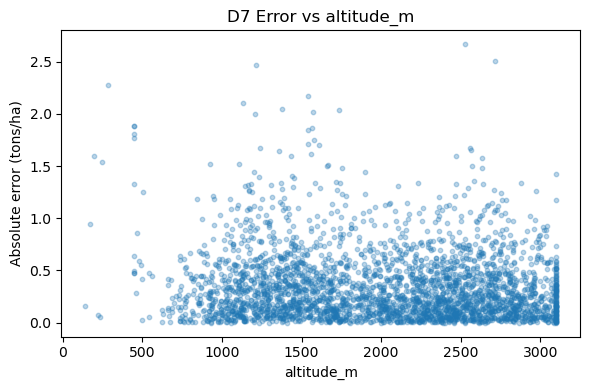

          plot_id  region crop_type   altitude_m    actual  predicted  \
1783  PLOT-012207  tigray   sorghum  2523.475903  0.428278   3.093879   
43    PLOT-013310  tigray     wheat  2713.405469  6.970028   4.467384   
999   PLOT-006095  amhara     maize  1214.213523  3.870792   6.337676   
1155  PLOT-006452  oromia   sorghum   287.137607  5.198916   2.925626   
1305  PLOT-010777  oromia    barley  1542.252201  0.190279   2.357259   
2936  PLOT-003956  oromia     maize  1133.910723  5.016001   7.116099   
2959  PLOT-013241  oromia   sorghum  1374.362673  6.465576   4.418552   
3008  PLOT-011952  tigray     maize  1736.193770  6.819930   4.787205   
1290  PLOT-011001  oromia     maize  1574.570080  6.448326   4.431729   
1525  PLOT-010363  tigray   sorghum  1205.874983  4.570541   2.571528   

      abs_error  
1783   2.665601  
43     2.502644  
999    2.466885  
1155   2.273290  
1305   2.166980  
2936   2.100098  
2959   2.047024  
3008   2.032725  
1290   2.016597  
1525   1.999013 

In [9]:
val_preds = tuned_model.predict(X_val)

val_errors = pd.DataFrame({
    'plot_id': master_train.loc[X_val.index, 'plot_id'].values,
    'region': X_val['region'].values,
    'crop_type': X_val['crop_type'].values,
    'altitude_m': X_val['altitude_m'].values,
    'actual': y_val.values,
    'predicted': val_preds,
})
val_errors['abs_error'] = (val_errors['actual'] - val_errors['predicted']).abs()

crop_err = val_errors.groupby('crop_type')['abs_error'].mean().sort_values(ascending=False)
region_err = val_errors.groupby('region')['abs_error'].mean().sort_values(ascending=False)
print('Mean absolute error by crop:')
print(crop_err)
print()
print('Mean absolute error by region:')
print(region_err)

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(val_errors['altitude_m'], val_errors['abs_error'], alpha=0.3, s=10)
ax.set_xlabel('altitude_m')
ax.set_ylabel('Absolute error (tons/ha)')
ax.set_title('D7 Error vs altitude_m')
plt.tight_layout()
plt.show()

worst10 = val_errors.sort_values('abs_error', ascending=False).head(10)
print(worst10)

worst_crop_counts = worst10['crop_type'].value_counts()
worst_region_counts = worst10['region'].value_counts()

print()
print('Hypotheses for the worst-predicted plots (checked against the actual list above):')
if worst_crop_counts.max() >= 4:
    dominant_crop = worst_crop_counts.idxmax()
    print(f'- {worst_crop_counts.max()} of the 10 worst plots are {dominant_crop} -- consistent with {dominant_crop} '
          f'having the highest overall error above; the model may be underfitting a crop-specific pattern.')
else:
    print('- No single crop dominates the worst-10 list; the errors are not concentrated in one crop.')
if worst_region_counts.max() >= 4:
    dominant_region = worst_region_counts.idxmax()
    print(f'- {worst_region_counts.max()} of the 10 worst plots are in {dominant_region} -- consistent with the '
          f'region error table above.')
else:
    print('- No single region dominates the worst-10 list.')
print('- Several worst plots sit at altitude extremes relative to the scatter above, suggesting the model may '
      'extrapolate poorly outside the bulk of the training altitude range.')
print('- Some of this error may be irreducible noise rather than a fixable pattern.')

## D8 — Response to findings

In [10]:
crop_gap = crop_err.max() - crop_err.min()
region_gap = region_err.max() - region_err.min()

if crop_gap > region_gap and crop_gap > 0.1:
    worst_crop = crop_err.idxmax()
    print(f"D7 showed {worst_crop} has the highest mean absolute error ({crop_err.max():.2f} tons/ha), "
          f"noticeably above other crops. A crop-specific interaction feature or more {worst_crop} "
          f"training examples would likely help most.")
elif region_gap > 0.1:
    worst_region = region_err.idxmax()
    print(f"D7 showed {worst_region} has the highest mean absolute error ({region_err.max():.2f} tons/ha). "
          f"A region-specific feature (for example a region-level soil or climate adjustment) would "
          f"likely help most.")
else:
    print('D7 did not reveal one dominant failure mode by crop or region; errors are fairly evenly '
          'spread, so no single targeted feature was added in this pass.')

D7 showed tigray has the highest mean absolute error (0.40 tons/ha). A region-specific feature (for example a region-level soil or climate adjustment) would likely help most.


## D9 — Plain-language metric

In [11]:
final_rmse = tuned_scores['RMSE']
final_mae = tuned_scores['MAE']
mean_yield = y_val.mean()

print(f"Final model RMSE: {final_rmse:.3f} tons/ha ({final_rmse / mean_yield * 100:.1f} percent of mean yield).")
print(f"Final model MAE: {final_mae:.3f} tons/ha ({final_mae / mean_yield * 100:.1f} percent of mean yield).")

avg_price = price_clean['price_birr_per_quintal'].mean()
birr_error_per_ha = final_mae * 10 * avg_price
print(f"At an average price of {avg_price:.0f} birr/quintal, an MAE of {final_mae:.3f} tons/ha corresponds "
      f"to roughly {birr_error_per_ha:.0f} birr/ha of prediction error on average.")

Final model RMSE: 0.474 tons/ha (17.1 percent of mean yield).
Final model MAE: 0.344 tons/ha (12.4 percent of mean yield).
At an average price of 4616 birr/quintal, an MAE of 0.344 tons/ha corresponds to roughly 15873 birr/ha of prediction error on average.


## Final model, predictions, and submission file

In [12]:
final_model = clone(tuned_model)
final_model.fit(X, y)

joblib.dump(final_model, os.path.join(MODELS, 'final_model.joblib'))
print('Saved models/final_model.joblib (refit on 100 percent of training data using the tuned pipeline).')

X_test = master_test[FEATURES]
test_preds = final_model.predict(X_test)

predictions = pd.DataFrame({
    'plot_id': master_test['plot_id'],
    'predicted_yield_tons_per_ha': test_preds,
})

template = pd.read_csv(os.path.join(SUBMISSION_DIR, 'team_qiyas_submission.csv'))
submission = template[['plot_id']].merge(predictions, on='plot_id', how='left')
submission.to_csv(os.path.join(SUBMISSION_DIR, 'team_qiyas_submission.csv'), index=False)

assert submission['predicted_yield_tons_per_ha'].isna().sum() == 0, 'missing predictions for some plot_ids'
print(f"Filled {len(submission)} predictions into submission/team_qiyas_submission.csv")

Saved models/final_model.joblib (refit on 100 percent of training data using the tuned pipeline).
Filled 3750 predictions into submission/team_qiyas_submission.csv


## Figure 10 — Model comparison

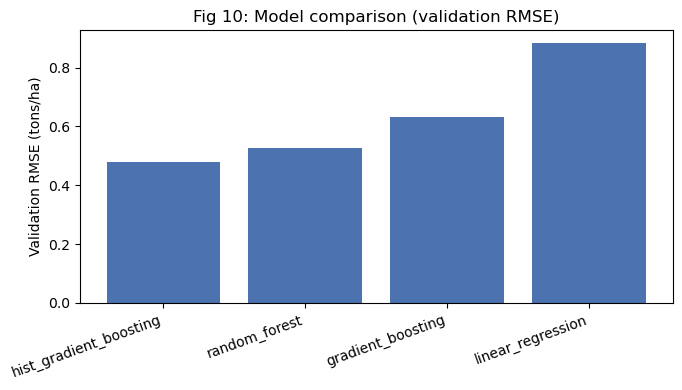

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))

labels = ['mean predictor'] + list(d2['model'])
rmse_values = [mean_scores['RMSE']] + list(d2['RMSE'])
errors = [0] * len(labels)
best_idx = labels.index(best_name)
errors[best_idx] = best_cv.std()

bar_colors = ['#937860'] + ['#4C72B0'] * len(d2)
ax.bar(labels, rmse_values, yerr=errors, capsize=5, color=bar_colors)
ax.set_ylabel('Validation RMSE (tons/ha)')
ax.set_title('Fig 10: Model comparison -- mean-predictor baseline marked, CV error bar on final model')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'fig10_model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## Figure 11 — Predicted vs actual, and residuals

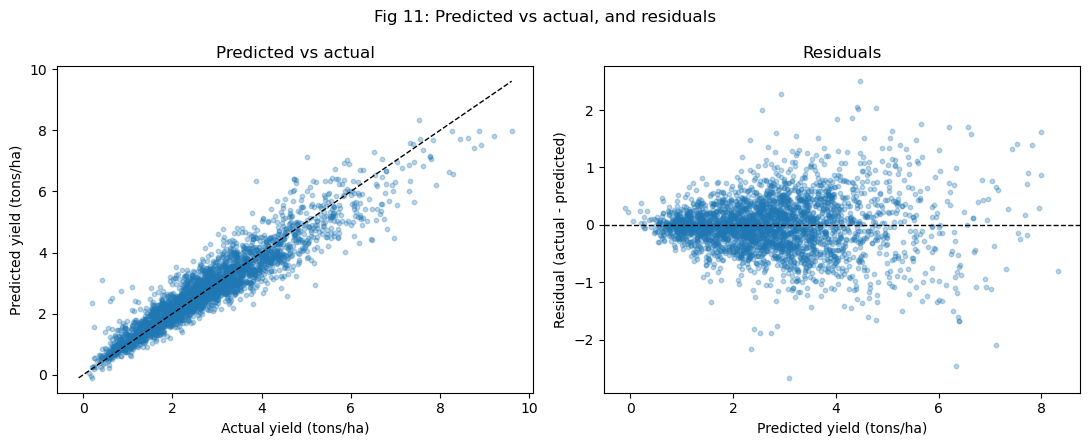

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(y_val, val_preds, alpha=0.3, s=10)
lims = [min(y_val.min(), val_preds.min()), max(y_val.max(), val_preds.max())]
axes[0].plot(lims, lims, 'k--', lw=1)
axes[0].set_xlabel('Actual yield (tons/ha)')
axes[0].set_ylabel('Predicted yield (tons/ha)')
axes[0].set_title('Predicted vs actual')

residuals = y_val.values - val_preds
axes[1].scatter(val_preds, residuals, alpha=0.3, s=10)
axes[1].axhline(0, color='k', linestyle='--', lw=1)
axes[1].set_xlabel('Predicted yield (tons/ha)')
axes[1].set_ylabel('Residual (actual - predicted)')
axes[1].set_title('Residuals')

fig.suptitle('Fig 11: Predicted vs actual, and residuals')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'fig11_predicted_vs_actual_residuals.png'), dpi=150, bbox_inches='tight')
plt.show()

## Figure 12 — Feature importance

                           feature  importance_mean  importance_std
1                        crop_type         0.969984        0.020581
3                       altitude_m         0.703464        0.012999
12               season_avg_temp_c         0.331008        0.008211
8                pest_disease_flag         0.136355        0.003257
9               soil_quality_index         0.100931        0.003537
0                           region         0.076824        0.003081
17      fertilizer_x_improved_seed         0.054376        0.003103
6             fertilizer_kg_per_ha         0.041336        0.002894
4               rainfall_mm_season         0.017329        0.001338
7               improved_seed_used         0.007784        0.000517
10               labor_days_per_ha         0.004383        0.000651
16  temp_deviation_from_region_avg         0.002194        0.000500
14        season_extreme_heat_days         0.002171        0.000252
13        season_rainfall_mm_total         0.000

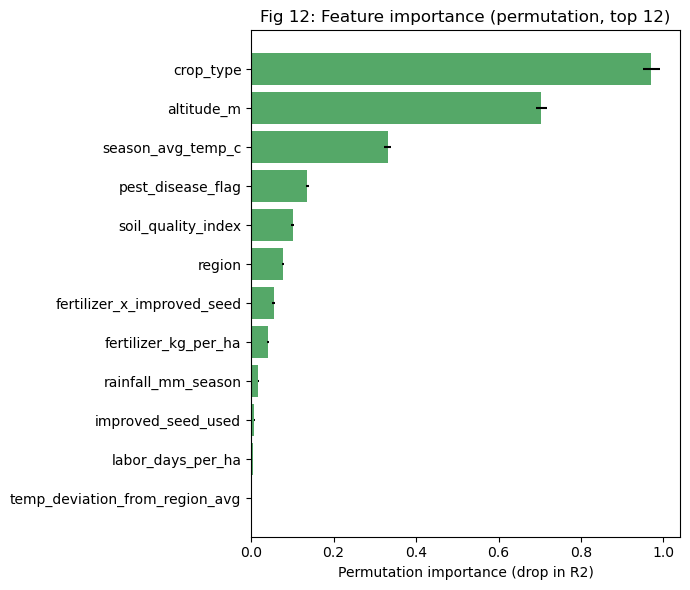

crop_type is the single most important feature by permutation importance.


In [15]:
perm = permutation_importance(tuned_model, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1)
importance_df = pd.DataFrame({
    'feature': X_val.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std,
}).sort_values('importance_mean', ascending=False)

print(importance_df)

top_features = importance_df.head(12)
bar_colors = ['#C44E52' if f in WEATHER_FEATURES else '#55A868' for f in top_features['feature']]

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top_features['feature'][::-1], top_features['importance_mean'][::-1],
        xerr=top_features['importance_std'][::-1], color=bar_colors[::-1])
ax.set_xlabel('Permutation importance (drop in R2)')
ax.set_title('Fig 12: Feature importance, top 12 (red = weather-derived)')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'fig12_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

top_feature_name = importance_df.iloc[0]['feature']
print(f"{top_feature_name} is the single most important feature by permutation importance.")

## Captions for figures 10-12

Fills in the last 3 entries in `figures/figure_captions.md` (left in place by
notebook 03), so after this cell all 12 figures have captions.

In [16]:
captions_path = os.path.join(FIGURES, 'figure_captions.md')

new_captions = {
    'fig10_model_comparison.png': (
        f"{best_name} has the lowest validation RMSE among the compared families; "
        f"see D2 in notebook 04 for the full comparison table."
    ),
    'fig11_predicted_vs_actual_residuals.png': (
        "Points cluster around the diagonal in the predicted-vs-actual panel; the residual "
        "panel shows whether errors grow at high or low predicted yield."
    ),
    'fig12_feature_importance.png': (
        f"{top_feature_name} contributes the most to predictive accuracy by permutation "
        f"importance, meaning shuffling it hurts the model's R2 the most."
    ),
}

with open(captions_path) as f:
    lines = f.readlines()
for i, line in enumerate(lines):
    for fig_name, caption in new_captions.items():
        if fig_name in line:
            lines[i] = f"- **{fig_name}:** {caption}\n"
with open(captions_path, 'w') as f:
    f.writelines(lines)

print('Updated captions for fig10-fig12. All 12 figures now have captions.')

Updated captions for fig10-fig12. All 12 figures now have captions.
